### Hyper-parameters

In [1]:
import os
import pandas as pd
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import ast

In [19]:
actor_num = 1 # LDA 진행하고자 하는 actor 번호; 0~4
topic_num_ = 5 # topic 개수

In [3]:
df = pd.read_csv(f'../clustering/results_clustering/ActorClustering_kmeans_kure_128_k5_bigram.csv', encoding='utf-8-sig')

print(len(df))
df.head()

58314


,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프..."
1,1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,"['하지불안 증후군', '다리', '감각', '느끼다', '해소', '위하다', '...",[ 0.02329755 0.33748412 5.701536 10.034008...,2,"['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '..."
2,2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['트다', '살', '크림', '종류', '많다', '알아보다', '종류', '다...",[4.2346669e-03 1.8436287e-02 9.1599712e+00 8.8...,4,"['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ..."
3,3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,"['셀프', '산후', '조리', '시작', '완', '산후', '도우미', '부르...",[0.02605256 0.21050377 7.150107 9.429928 1...,2,"['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산..."
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다..."


In [4]:
df['tokenized'] = df['bigram']
df.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...","['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프..."
1,1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,"['하지불안 증후군', '다리', '감각', '느끼다', '해소', '위하다', '...",[ 0.02329755 0.33748412 5.701536 10.034008...,2,"['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '...","['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '..."
2,2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['트다', '살', '크림', '종류', '많다', '알아보다', '종류', '다...",[4.2346669e-03 1.8436287e-02 9.1599712e+00 8.8...,4,"['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ...","['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ..."
3,3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,"['셀프', '산후', '조리', '시작', '완', '산후', '도우미', '부르...",[0.02605256 0.21050377 7.150107 9.429928 1...,2,"['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산...","['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산..."
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...","['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다..."


# ◆ 1. LDA를 위한 데이터 전처리
* 1.1. 전체 단어의 사전 만들고 각 문서에 매칭하기
    > 단어들이 문서에 얼마나 위치해 있는지 분포를 파악해야하기 때문에 분석할 전체 데이터 대상으로
    사용된 단어의 사전을 생성해야한다,


In [5]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary

### 1.1 전체 단어의 사전 만들고 각 문서에 매칭하기

In [6]:
# cluster 0
df_cluster0 = df[df['cluster'] == actor_num]
print(len(df_cluster0))
df_cluster0.head()

12938


,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...","['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프..."
5,5,네이버카페_레몬테라스,육아일기,월 일인데 오늘도 치우고만 있네요,하루 종일 치우고 또 치우고 끝이 없어요 내일이면 새해라니 남의 일 같아요 그냥 오...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['하루', '종일', '치우다', '치우다', '끝', '내일', '새해', '남...",[6.6124848e-03 1.8286444e-02 9.7138691e+00 7.9...,1,"['하루_종일', '종일_치우다', '치우다_치우다', '치우다_끝', '끝_내일'...","['하루_종일', '종일_치우다', '치우다_치우다', '치우다_끝', '끝_내일'..."
7,7,네이버카페_레몬테라스,육아일기,년에 살 되는 여자아기 선물추천 해주세요,만원 선으로 뭐가 좋을까요 아이를 키워 본지가 오래 되어서 감이 안오네요,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['선', '좋다', '키우다', '감', '오다']",[ 9.6352883e-03 -2.0319456e-02 1.0137810e+01 ...,1,"['선_좋다', '좋다_키우다', '키우다_감', '감_오다']","['선_좋다', '좋다_키우다', '키우다_감', '감_오다']"
14,14,네이버카페_맘이베베,육아질문방,제왕절개로해서 낳을예정인데요,월말생이 낳을까요 월초생으로 낳을까요 저희가족은 다들 말생이예요 일부터 일까지 생일이네요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['월말', '낳다', '낳다', '가족', '말', '생일']",[0.00982533 0.02780871 9.4822035 8.560233 3...,1,"['월말_낳다', '낳다_낳다', '낳다_가족', '가족_말', '말_생일']","['월말_낳다', '낳다_낳다', '낳다_가족', '가족_말', '말_생일']"
35,35,네이버카페_맘이베베,육아질문방,법인 대표자 아내는 육아휴직 급여 못받나요,저는 남편이랑 년을 연애하고 결혼했어요 남편이 연애 년차쯤 사업을 시작해서 같이 회...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['남편', '연애', '결혼', '남편', '연애', '사업', '시작', '회사...",[0.01820497 0.03834931 9.22266 8.434765 1...,1,"['남편_연애', '연애_결혼', '결혼_남편', '남편_연애', '연애_사업', ...","['남편_연애', '연애_결혼', '결혼_남편', '남편_연애', '연애_사업', ..."


In [7]:
# 1. 문자열을 실제 리스트로 변환해주는 함수
def parse_tokens(text):
    if isinstance(text, str):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            # 만약 "단어1 단어2" 형태의 단순 띄어쓰기 문자열이라면 split() 적용
            return text.split()
    return text

# 2. 'tokenized' 컬럼에 함수 적용 후 리스트로 변환
all_documents = df_cluster0['tokenized'].apply(parse_tokens).tolist()

# 3. 사전(Dictionary) 생성
dictionary = Dictionary(all_documents)

# 결과 확인
print(f"단어장 생성 완료! 총 단어 개수: {len(dictionary)}")
dictionary.token2id  # 필요 시 주석 해제하여 확인

단어장 생성 완료! 총 단어 개수: 220538


{'다중_말': 0,
 '돌_전': 1,
 '돌_지나다': 2,
 '돌다_아기': 3,
 '말_돌다': 4,
 '사다_프뢰벨': 5,
 '아기_전집': 6,
 '영아_다중': 7,
 '전_집': 8,
 '전집_추천': 9,
 '지나다_돌': 10,
 '집_사다': 11,
 '추천_부탁드리다': 12,
 '프뢰벨_영아': 13,
 '끝_내일': 14,
 '남_오늘': 15,
 '내일_새해': 16,
 '똑같다_하루': 17,
 '새해_남': 18,
 '오늘_똑같다': 19,
 '종일_치우다': 20,
 '치우다_끝': 21,
 '치우다_치우다': 22,
 '하루_종일': 23,
 '감_오다': 24,
 '선_좋다': 25,
 '좋다_키우다': 26,
 '키우다_감': 27,
 '가족_말': 28,
 '낳다_가족': 29,
 '낳다_낳다': 30,
 '말_생일': 31,
 '월말_낳다': 32,
 '가리다_근무': 33,
 '결혼_남편': 34,
 '결혼_전': 35,
 '공부_궂다': 36,
 '관리_회사': 37,
 '관리직_근무': 38,
 '궂다_가리다': 39,
 '근무_근무': 40,
 '근무_아래': 41,
 '근무_오늘': 42,
 '근무_혼인': 43,
 '급여_내년': 44,
 '남편_연애': 45,
 '내년_출산': 46,
 '내다_싸우다': 47,
 '대표_와이프': 48,
 '대하다_증빙': 49,
 '멘붕_애기': 50,
 '사실_알다': 51,
 '사업_시작': 52,
 '상황_육아': 53,
 '시작_회사': 54,
 '신고_증빙': 55,
 '싸우다_상황': 56,
 '아래_직원': 57,
 '알다_대표': 58,
 '알다_멘붕': 59,
 '애기_결혼': 60,
 '연애_결혼': 61,
 '연애_사업': 62,
 '오늘_알다': 63,
 '와이프_육아': 64,
 '운영_관리직': 65,
 '육아_휴직': 66,
 '자료_내다': 67,
 '자료_차다': 68,
 '전_근무': 69,
 '증빙_자료': 70,
 '증빙_증빙': 71

In [8]:
corpus = []
for doc in all_documents:
    corpus.append(dictionary.doc2bow(doc))
    
corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1)],
 [(14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 1)],
 [(24, 1), (25, 1), (26, 1), (27, 1)],
 [(28, 1), (29, 1), (30, 1), (31, 1), (32, 1)],
 [(33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 2),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 1),
  (57, 1),
  (58, 1),
  (59, 1),
  (60, 1),
  (61, 1),
  (62, 1),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 2),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 2),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 1),
  (82, 1),
  (83, 1)],
 [(84, 1), (85, 1), (86, 1), (87, 1)],
 [(88, 1),
  (89, 1),
  (90, 1),
  (91, 1),
  (92, 1),
 

# ◆ 2. LDA모델 만들기
* 2.1 LDA 기본 모델 만들기
* 2.2 LDA 토픽개수 선정
* 2.3 선정한 토픽 개수로 Action 넘버 매칭

### 2.1 LDA 기본 모델 만들기

In [9]:
# topic_num = 4 # 3 
# ldamodel = gensim.models.ldamodel.LdaModel(corpus,
#                                            num_topics= topic_num,
#                                            id2word= dictionary,
#                                            passes= 20,
#                                            iterations= 50,
#                                            random_state= 42)

In [10]:
# ldamodel.print_topics(num_words= 10)

In [11]:
# for i in range(int(len(corpus)/100)):
#     print(ldamodel.get_document_topics(corpus[i]))

### 2.2 LDA 토픽 수 선정
* cohearence & perplexcity

In [12]:
from gensim.models import CoherenceModel # coherence 모델 라이브러리
import matplotlib.pyplot as plt # 그래프 그리기
import numpy as np

> 2.2.1 Perplexity 그래프 만들기

In [13]:
perplexity_values = []

for i in range(2, 10):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    perplexity_v = np.exp(-ldamodel.log_perplexity(corpus))
    perplexity_values.append(perplexity_v)

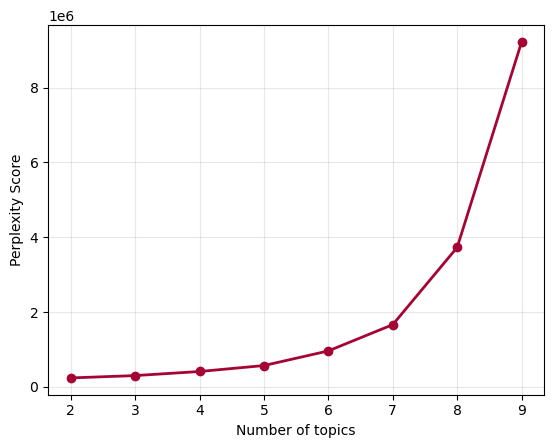

In [14]:
x = range(2, 10)

plt.plot(
    x,
    perplexity_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Perplexity Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'./results/LDA_Actor{actor_num}_action_cluster_perplexity_plot.png', dpi=300, transparent=True)
plt.show()

In [15]:
# perplexity 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, perplexity_values]).T
result0.columns = ['n_cluster', 'perplexity_values']
result0.to_excel(f'./results/LDA_Actor{actor_num}_action_cluster_perplexity.xlsx', index=False)

> 2.2.1 Coherence 그래프 만들기

In [16]:
coherence_values = []
top_n = 3

for i in tqdm(range(2,10)):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    coherence_model = CoherenceModel(model= ldamodel,
                                 texts= all_documents,
                                 dictionary= dictionary,
                                 topn= top_n)
    
    coherence_score = coherence_model.get_coherence()
    coherence_values.append(coherence_score)

100%|██████████| 8/8 [01:29<00:00, 11.16s/it]


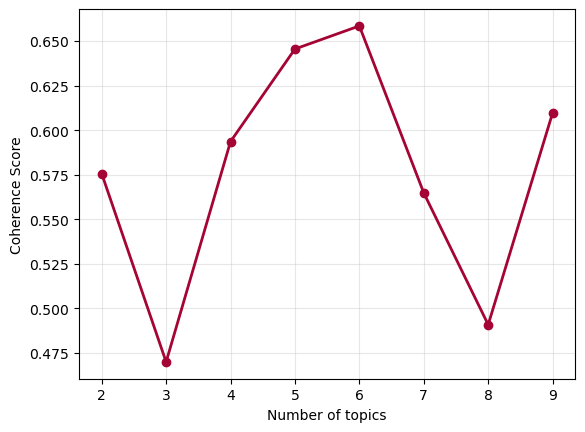

In [17]:
x = range(2, 10)

plt.plot(
    x,
    coherence_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Coherence Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'./results/LDA_Actor{actor_num}_action_cluster_coherance_plot.png', dpi=300, transparent=True)
plt.show()

In [18]:
# Coherance 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, coherence_values]).T
result0.columns = ['n_cluster', 'coherence_values']
result0.to_excel(f'./results/LDA_Actor{actor_num}_action_cluster_coherence.xlsx', index=False)

### 2.3 선정한 토픽 개수로 Action 넘버 매칭

In [20]:
topic_num = topic_num_ # 3

ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                           num_topics= topic_num,
                                           id2word= dictionary,
                                           passes= 20,
                                           iterations= 50,
                                           random_state= 42)

In [21]:
ldamodel.get_document_topics(corpus)[2]

[(0, 0.040460855),
 (1, 0.8378799),
 (2, 0.040495485),
 (3, 0.04054886),
 (4, 0.040614955)]

In [22]:
action_align = []

for doc in tqdm(ldamodel.get_document_topics(corpus)):
    label = []
    value = []
    
    for score in doc:
        label.append(score[0])
        value.append(score[1])
        
    max_index = np.argmax(value)
    action_n = label[max_index]
    action_align.append(action_n)
    

100%|██████████| 12938/12938 [00:01<00:00, 9160.59it/s]


In [23]:
df_cluster0['action_cluster'] = action_align
df_cluster0.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized,action_cluster
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...","['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...",2
5,5,네이버카페_레몬테라스,육아일기,월 일인데 오늘도 치우고만 있네요,하루 종일 치우고 또 치우고 끝이 없어요 내일이면 새해라니 남의 일 같아요 그냥 오...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['하루', '종일', '치우다', '치우다', '끝', '내일', '새해', '남...",[6.6124848e-03 1.8286444e-02 9.7138691e+00 7.9...,1,"['하루_종일', '종일_치우다', '치우다_치우다', '치우다_끝', '끝_내일'...","['하루_종일', '종일_치우다', '치우다_치우다', '치우다_끝', '끝_내일'...",4
7,7,네이버카페_레몬테라스,육아일기,년에 살 되는 여자아기 선물추천 해주세요,만원 선으로 뭐가 좋을까요 아이를 키워 본지가 오래 되어서 감이 안오네요,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['선', '좋다', '키우다', '감', '오다']",[ 9.6352883e-03 -2.0319456e-02 1.0137810e+01 ...,1,"['선_좋다', '좋다_키우다', '키우다_감', '감_오다']","['선_좋다', '좋다_키우다', '키우다_감', '감_오다']",1
14,14,네이버카페_맘이베베,육아질문방,제왕절개로해서 낳을예정인데요,월말생이 낳을까요 월초생으로 낳을까요 저희가족은 다들 말생이예요 일부터 일까지 생일이네요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['월말', '낳다', '낳다', '가족', '말', '생일']",[0.00982533 0.02780871 9.4822035 8.560233 3...,1,"['월말_낳다', '낳다_낳다', '낳다_가족', '가족_말', '말_생일']","['월말_낳다', '낳다_낳다', '낳다_가족', '가족_말', '말_생일']",3
35,35,네이버카페_맘이베베,육아질문방,법인 대표자 아내는 육아휴직 급여 못받나요,저는 남편이랑 년을 연애하고 결혼했어요 남편이 연애 년차쯤 사업을 시작해서 같이 회...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['남편', '연애', '결혼', '남편', '연애', '사업', '시작', '회사...",[0.01820497 0.03834931 9.22266 8.434765 1...,1,"['남편_연애', '연애_결혼', '결혼_남편', '남편_연애', '연애_사업', ...","['남편_연애', '연애_결혼', '결혼_남편', '남편_연애', '연애_사업', ...",3


In [24]:
df_cluster0['action_cluster'].value_counts()

action_cluster
0    3093
2    2637
1    2585
4    2516
3    2107
Name: count, dtype: int64

# ◆ 3. LDA 시각화 (LDAvis)


In [25]:
# !pip install pyLDAvis

In [26]:
#경고무시
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#LDA 시각화 라이브러리
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [27]:
prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary)
# pyLDAvis.save_html(prepared_data, f'{output_path}/ldavis_Actor_{actor_num}.html')
pyLDAvis.save_html(prepared_data, f'./results/LDA_Actor{actor_num}_ldavis.html')
# pyLDAvis.display(prepared_data)

In [28]:
pyLDAvis.display(prepared_data)

# ◆ 4. LDA 분석을 위한 후작업
* LDAvis와 LDA모델의 토픽 넘버 매칭
* LDAvis 결과와 LDA모델의 결과를 보고 직접 매칭해야한다.

In [29]:
topics = ldamodel.show_topics(num_topics= -1, # - 1 은 다 가져오라는것
                              formatted= True,
                              )

for topic_id, topic_desc in topics :
    print(f"Topic ID : {topic_id}, Description : {topic_desc}")

Topic ID : 0, Description : 0.002*"문_세다" + 0.002*"엄마_아빠" + 0.002*"가지다_놀다" + 0.001*"책_읽다" + 0.001*"부탁_드리다" + 0.001*"추천_부탁드리다" + 0.001*"근육_발달" + 0.001*"집_놀다" + 0.001*"장난감_추천" + 0.001*"언어_치료"
Topic ID : 1, Description : 0.006*"어린이집_보내다" + 0.005*"육아_휴직" + 0.003*"가정_어린이집" + 0.003*"연락_오다" + 0.003*"어린이집_입소" + 0.002*"대기_걸다" + 0.002*"어린이집_다니다" + 0.002*"얼_집" + 0.002*"가정_보육" + 0.002*"국공립_어린이집"
Topic ID : 2, Description : 0.003*"부탁_드리다" + 0.003*"얼_집" + 0.002*"책_읽다" + 0.002*"추천_부탁" + 0.002*"담임_선생" + 0.001*"어린이집_다니다" + 0.001*"추천_부탁드리다" + 0.001*"책_추천" + 0.001*"레_미" + 0.001*"도_레"
Topic ID : 3, Description : 0.004*"조리_원" + 0.003*"산후_도우미" + 0.002*"출산_휴가" + 0.001*"행복_카드" + 0.001*"국민_행복" + 0.001*"출산_후" + 0.001*"친정_엄마" + 0.001*"임신_출산" + 0.001*"정부_지원" + 0.001*"집_오다"
Topic ID : 4, Description : 0.003*"소리_지르다" + 0.002*"밥_먹다" + 0.002*"짜증_내다" + 0.002*"엄마_아빠" + 0.001*"하루_종일" + 0.001*"집_오다" + 0.001*"책_읽다" + 0.001*"소리_내다" + 0.001*"사운드_북" + 0.001*"배_밀"


In [32]:
# 모델 LDAvis
# lda   ldavis
# 0     3
# 1     1
# 2     2
lda_ldavis_map = {0:'3',
                  1:'2',
                  2:'4',
                  3:'5',
                  4:'1'
                  }

In [33]:
new_action_topic = []

for i in df_cluster0['action_cluster'] :
    n = lda_ldavis_map[i]
    
    # if i == 0 :
    #     n = 3
    # elif i == 1 : 
    #     n = 1
    # elif i == 2 :
    #     n = 2
    # else : 
    #     n = 1
    new_action_topic.append(n)

In [34]:
df_cluster0['action_cluster'] = new_action_topic
df_cluster0.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized,action_cluster
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...","['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...",4
5,5,네이버카페_레몬테라스,육아일기,월 일인데 오늘도 치우고만 있네요,하루 종일 치우고 또 치우고 끝이 없어요 내일이면 새해라니 남의 일 같아요 그냥 오...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['하루', '종일', '치우다', '치우다', '끝', '내일', '새해', '남...",[6.6124848e-03 1.8286444e-02 9.7138691e+00 7.9...,1,"['하루_종일', '종일_치우다', '치우다_치우다', '치우다_끝', '끝_내일'...","['하루_종일', '종일_치우다', '치우다_치우다', '치우다_끝', '끝_내일'...",1
7,7,네이버카페_레몬테라스,육아일기,년에 살 되는 여자아기 선물추천 해주세요,만원 선으로 뭐가 좋을까요 아이를 키워 본지가 오래 되어서 감이 안오네요,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['선', '좋다', '키우다', '감', '오다']",[ 9.6352883e-03 -2.0319456e-02 1.0137810e+01 ...,1,"['선_좋다', '좋다_키우다', '키우다_감', '감_오다']","['선_좋다', '좋다_키우다', '키우다_감', '감_오다']",2
14,14,네이버카페_맘이베베,육아질문방,제왕절개로해서 낳을예정인데요,월말생이 낳을까요 월초생으로 낳을까요 저희가족은 다들 말생이예요 일부터 일까지 생일이네요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['월말', '낳다', '낳다', '가족', '말', '생일']",[0.00982533 0.02780871 9.4822035 8.560233 3...,1,"['월말_낳다', '낳다_낳다', '낳다_가족', '가족_말', '말_생일']","['월말_낳다', '낳다_낳다', '낳다_가족', '가족_말', '말_생일']",5
35,35,네이버카페_맘이베베,육아질문방,법인 대표자 아내는 육아휴직 급여 못받나요,저는 남편이랑 년을 연애하고 결혼했어요 남편이 연애 년차쯤 사업을 시작해서 같이 회...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['남편', '연애', '결혼', '남편', '연애', '사업', '시작', '회사...",[0.01820497 0.03834931 9.22266 8.434765 1...,1,"['남편_연애', '연애_결혼', '결혼_남편', '남편_연애', '연애_사업', ...","['남편_연애', '연애_결혼', '결혼_남편', '남편_연애', '연애_사업', ...",5


In [35]:
df_cluster0 = df_cluster0[['출처', '키워드', '제목', '내용', '작성일', '링크', 'tokenized', 'cluster', 'action_cluster']]

In [36]:
# csv 저장
df_cluster0.to_csv(f'./results/LDA_Actor{actor_num}_action_cluster.csv', encoding='utf-8-sig')

In [37]:
df_cluster0['action_cluster'].value_counts()

action_cluster
3    3093
4    2637
2    2585
1    2516
5    2107
Name: count, dtype: int64